In [1]:
import math
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from tqdm.notebook import tqdm
from urllib.request import urlretrieve
import pickle
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro

%load_ext rpy2.ipython

# Extract survey data response rates

In [2]:
simple_query = """
SELECT 
    question_concept_id,
    COUNT(*) / 413457 as response_rate,
    ANY_VALUE(survey) as survey,
    ANY_VALUE(question) as question
FROM
    (SELECT
        person_id,
        ANY_VALUE(survey) as survey,
        ANY_VALUE(question) as question,
        question_concept_id
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey`
    WHERE 
        NOT REGEXP_CONTAINS(answer, 'Prefer Not To Answer') AND
        answer NOT IN (
            'PMI: Skip',
            'PMI: Other',
            'PMI: Dont Know', 
            'Invalid',
            'No matching concept',
            'None',
            'Response removed due to invalid value'
            ) AND
        survey IN ('The Basics', 'Lifestyle', 'Healthcare Access & Utilization', 'Social Determinants of Health')
    GROUP BY person_id, question_concept_id)
GROUP BY question_concept_id
ORDER BY response_rate DESC
"""
all_questions = pd.read_gbq(
    simple_query,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")
all_questions

Downloading:   0%|          | 0/196 [00:00<?, ?rows/s]

,question_concept_id,response_rate,survey,question
0,1585838,0.980518,The Basics,Gender: Gender Identity
1,1585845,0.979478,The Basics,Biological Sex At Birth: Sex At Birth
2,1585879,0.976072,The Basics,Living Situation: How Many Living Years
3,1585852,0.975920,The Basics,Active Duty: Active Duty Serve Status
4,1585886,0.975727,The Basics,Living Situation: Stable House Concern
...,...,...,...,...
191,1585692,0.001250,Lifestyle,Past 3 Month Use Frequency: Street Opioid 3 Mo...
192,1585668,0.001151,Lifestyle,Past 3 Month Use Frequency: Other Stimulant 3 ...
193,1585348,0.000832,The Basics,Gender: Closer Gender Description
194,1585674,0.000830,Lifestyle,Past 3 Month Use Frequency: Inhalant 3 Month Use


In [3]:
print(all_questions['survey'].value_counts())

survey
Social Determinants of Health      81
Healthcare Access & Utilization    57
Lifestyle                          31
The Basics                         27
Name: count, dtype: int64


In [4]:
all_questions.to_csv('all_question_response_rate.tsv', sep='\t', index=False)

# Common questions to use in MCA (excluding zip metrics)

In [5]:
QUESTIONS_TO_TAKE = 136
survey_columns = ['q%s' % i for i in range(QUESTIONS_TO_TAKE)]

survey_order = {'The Basics': 1, 'Lifestyle': 2, 'Healthcare Access & Utilization': 3,
                'Social Determinants of Health': 4}

In [6]:
simple_query = """
SELECT 
    question_concept_id,
    COUNT(*) as response_count,
    ANY_VALUE(survey) as survey,
    ANY_VALUE(question) as question
FROM
    (SELECT
        person_id,
        ANY_VALUE(survey) as survey,
        ANY_VALUE(question) as question,
        question_concept_id
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey`
    WHERE 
        NOT REGEXP_CONTAINS(answer, 'Prefer Not To Answer') AND
        answer NOT IN (
            'PMI: Skip',
            'PMI: Other',
            'PMI: Dont Know', 
            'Invalid',
            'No matching concept',
            'None',
            'Response removed due to invalid value'
            ) AND
        question_concept_id NOT IN (
        1585838,
        1585845,
        1586140,
        903573,
        903574,
        903577,
        903576,
        903578,
        903575) AND 
        # Gender, Sex, Race/Ethnicity, Deaf, Blind, Dressing/Bathing, Walking/Climbing, Errands alone, Concentrating
        survey IN ('The Basics', 'Lifestyle', 'Healthcare Access & Utilization', 'Social Determinants of Health')
    GROUP BY person_id, question_concept_id)
GROUP BY question_concept_id
ORDER BY response_count DESC
LIMIT """ + str(QUESTIONS_TO_TAKE)

common_questions = pd.read_gbq(
    simple_query,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

common_questions = common_questions.sort_values(by='survey',
                                                key=lambda x: x.apply(lambda y : survey_order[y])).reset_index(drop=True)

Downloading:   0%|          | 0/136 [00:00<?, ?rows/s]

In [7]:
print(common_questions['survey'].value_counts())
print(common_questions.shape)

survey
Social Determinants of Health      59
Healthcare Access & Utilization    46
Lifestyle                          17
The Basics                         14
Name: count, dtype: int64
(136, 4)


In [8]:
common_questions.to_csv('common_questions.tsv', sep='\t', index=False)

# Survey data, zip and self-reported race/ethnicity/gender/sex

In [9]:
dataset_07211334_zip_code_socioeconomic_sql = """
SELECT 
    person.person_id,
    assisted_income,
    high_school_education,
    median_income,
    no_health_insurance,
    poverty,
    vacant_housing,
    deprivation_index,
    zip_code,
    """ + ', '.join(survey_columns) + """,
    p_gender_concept.concept_name as gender,
    p_race_concept.concept_name as race,
    p_ethnicity_concept.concept_name as ethnicity,
    p_sex_at_birth_concept.concept_name as sex_at_birth
FROM
    `""" + os.environ["WORKSPACE_CDR"] + """.person` person
LEFT JOIN    
    (SELECT
        observation.person_id,
        MAX(zip_code.zip3_as_string) as zip_code,
        MAX(zip_code.fraction_assisted_income) as assisted_income,
        MAX(zip_code.fraction_high_school_edu) as high_school_education,
        MAX(zip_code.median_income) as median_income,
        MAX(zip_code.fraction_no_health_ins) as no_health_insurance,
        MAX(zip_code.fraction_poverty) as poverty,
        MAX(zip_code.fraction_vacant_housing) as vacant_housing,
        MAX(zip_code.deprivation_index) as deprivation_index
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.zip3_ses_map` zip_code 
    JOIN
        (SELECT person_id,
                CAST(substr(value_as_string, 0, 3) as INT64) as zip3
         FROM `""" + os.environ["WORKSPACE_CDR"] + """.observation`
         WHERE STRPOS(value_as_string, '*') > 0) observation
            ON observation.zip3 = zip_code.zip3
    GROUP BY person_id) as zip_data
        ON zip_data.person_id = person.person_id
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_gender_concept 
        ON person.gender_concept_id = p_gender_concept.concept_id 
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_race_concept 
        ON person.race_concept_id = p_race_concept.concept_id 
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_ethnicity_concept 
        ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id 
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_sex_at_birth_concept 
        ON person.sex_at_birth_concept_id = p_sex_at_birth_concept.concept_id
LEFT JOIN
   (SELECT
        person_id,
""" + ''.join([('MAX(_%s) as q%s,') % (q, i) for i, q in common_questions['question_concept_id'].items()]) + """
    FROM
        (SELECT *
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey`
        WHERE 
            NOT REGEXP_CONTAINS(answer, 'Prefer Not To Answer') AND 
            answer NOT IN (
                    'PMI: Skip', 'PMI: Other', 'PMI: Dont Know', 'Invalid', 'No matching concept', 'None',
                    'Response removed due to invalid value'))
    PIVOT (ANY_VALUE(answer) for question_concept_id IN (
    """ + ','.join(common_questions['question_concept_id'].apply(str).to_list()) +  """))
    GROUP BY person_id) as survey_data
ON person.person_id = survey_data.person_id"""

survey_and_zip_data = pd.read_gbq(
    dataset_07211334_zip_code_socioeconomic_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")

Downloading:   0%|          | 0/413457 [00:00<?, ?rows/s]

In [10]:
survey_and_zip_data.shape

(413457, 149)

In [11]:
survey_and_zip_data.to_parquet('survey_and_zip_data.parquet', engine='pyarrow')

In [12]:
survey_and_zip_data = pd.read_parquet('survey_and_zip_data.parquet', engine='pyarrow')

# Generate MCA

## Convert survey data to categorial values

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def quantize(x, quantiles):
    for floor, idx in reversed(list(zip(quantiles, range(len(quantiles))))):
        if x >= floor:
            return 'quantile_%s_of_%s' % (idx + 1, len(quantiles))
    return None

categorized = pd.DataFrame()
for col in survey_columns:
    if all([x.isnumeric() for x in survey_and_zip_data[col].value_counts().index]):
        as_floats = [float(x) if x is not None else np.nan for x in survey_and_zip_data[col]]
        quantiles = np.nanquantile(as_floats, [0.0, 0.2, 0.4, 0.6, 0.8])
        categorized[col] = [quantize(x, quantiles) for x in as_floats]
        categorized[col] = categorized[col].astype('category')
    else:
        categorized[col] = survey_and_zip_data[col].astype('category')

zip_vars = ['assisted_income', 'high_school_education', 'median_income', 'no_health_insurance', 'poverty', 
            'vacant_housing', 'deprivation_index']

for col in zip_vars[0:-1]:
    as_floats = [float(x) if x is not None else np.nan for x in survey_and_zip_data[col]]
    quantiles = np.nanquantile(as_floats, [0.0, 0.2, 0.4, 0.6, 0.8])
    categorized[col] = [quantize(x, quantiles) for x in as_floats]
    categorized[col] = categorized[col].astype('category')

continuous_vars = pd.DataFrame(make_pipeline(SimpleImputer(), StandardScaler()).fit_transform(
    survey_and_zip_data[zip_vars]), columns=zip_vars) # survey_and_zip_data
categorized.columns = common_questions['question'].tolist() + categorized.columns.tolist()[-6:]

In [14]:
categorized.shape # 142 = 136 questions + 6 zip-measurements

(413457, 142)

In [15]:
categorized.to_parquet('categorized.parquet', engine='pyarrow')

In [16]:
categorized = pd.read_parquet('categorized.parquet', engine='pyarrow')

## MCA with ade4 in R

In [17]:
with (ro.default_converter + pandas2ri.converter).context():
    df = ro.conversion.get_conversion().py2rpy(categorized)

In [18]:
%%R -i df

requiredPackages = c(
    'ade4'
)
for(p in requiredPackages){
  if(!require(p,character.only = TRUE)) install.packages(p)
  library(p,character.only = TRUE)
}

print("libraries loaded.")
col_names <- names(df)
df[,col_names] <- lapply(df[,col_names], factor)
res.mca = dudi.acm(df, scannf = FALSE, nf = 50)
print("MCA complete.")

[1] "libraries loaded."
[1] "MCA complete."


Loading required package: ade4


In [19]:
%%R -i df

print(res.mca)

Duality diagramm
class: acm dudi
$call: dudi.acm(df = df, scannf = FALSE, nf = 50)

$nf: 50 axis-components saved
$rank: 570
eigen values: 0.3755 0.1104 0.09494 0.05854 0.04377 ...
  vector length mode    content       
1 $cw    575    numeric column weights
2 $lw    413457 numeric row weights   
3 $eig   570    numeric eigen values  

  data.frame nrow   ncol content             
1 $tab       413457 575  modified array      
2 $li        413457 50   row coordinates     
3 $l1        413457 50   row normed scores   
4 $co        575    50   column coordinates  
5 $c1        575    50   column normed scores
other elements: cr 


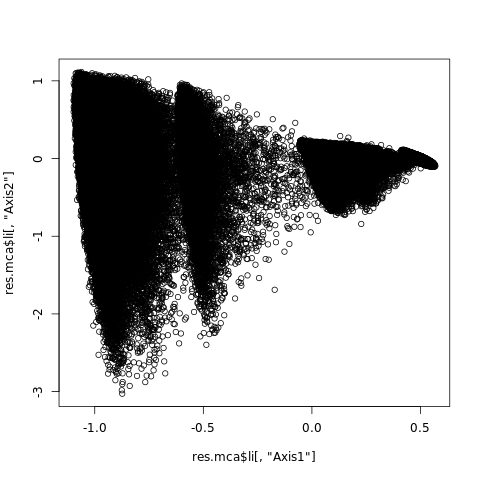

In [20]:
%%R -i df

# principal components, data frame with n rows and nf columns
plot(res.mca$li[, "Axis1"], res.mca$li[, "Axis2"])

In [21]:
%%R -i df

saveRDS(res.mca, "res.mca.rds")

In [22]:
%%R

principal_components <- res.mca$li

In [23]:
projections = np.asarray(ro.globalenv['principal_components']).transpose((1, 0))

print(projections.shape)

mca_columns = ['mca_axis_%s' % i for i in range(projections.shape[1])]
proj_df = pd.DataFrame(data=projections, columns=mca_columns)
low_dim_survey_df = pd.concat(
    [survey_and_zip_data[['person_id', 'gender', 'race', 'ethnicity', 'sex_at_birth']], proj_df],
    axis=1)

(413457, 50)


In [25]:
low_dim_survey_df.shape

(413457, 55)

In [26]:
low_dim_survey_df.to_parquet('low_dim_survey_df.parquet', engine='pyarrow')

In [27]:
low_dim_survey_df = pd.read_parquet('low_dim_survey_df.parquet', engine='pyarrow')

# Get all ICD codes

In [28]:
def getIcdsForPersons():
    simple_query = """
    SELECT
        person_id,
        array_agg(distinct(condition_source_value)) as top_level_code
    FROM `""" + os.environ["WORKSPACE_CDR"] + """.condition_occurrence`
    WHERE condition_source_value is not null
    GROUP BY person_id
    """
    # get all conditions for input person
    return pd.read_gbq(
        simple_query,
        dialect="standard",
        use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
        progress_bar_type="tqdm_notebook")

everything_for_everyone = getIcdsForPersons()

Downloading:   0%|          | 0/254114 [00:00<?, ?rows/s]

In [29]:
everything_for_everyone.to_parquet('everything_for_everyone.parquet', engine='pyarrow')

In [30]:
max_ageverything_for_everyonee_df = pd.read_parquet('everything_for_everyone.parquet', engine='pyarrow')

# Get age data

In [31]:
simple_query = """ 
WITH
    Last_Visit AS (
        SELECT 
            person_id, 
            MAX(visit_end_date) as last_seen
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.visit_occurrence`
        GROUP BY person_id
    ),
    Last_Measurement AS (
        SELECT 
            person_id, 
            MAX(measurement_date) as latest_measurement
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.measurement`
        GROUP BY person_id
    ),
    Last_Observation AS (
        SELECT 
            person_id, 
            MAX(observation_date) as latest_observation
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.observation`
        GROUP BY person_id
    ),
    Last_Survey AS (
        SELECT 
            person_id, 
            DATE(MAX(survey_datetime)) as latest_survey
        FROM
            `""" + os.environ["WORKSPACE_CDR"] + """.ds_survey`
        GROUP BY person_id
    ),
    Last_Condition AS (
        SELECT
            person_id,
            MAX(condition_start_date) as latest_condition
        FROM `""" + os.environ["WORKSPACE_CDR"] + """.condition_occurrence`
        GROUP BY person_id),
    # really, this is a whole thing
    Earliest_Death AS (
        SELECT person_id, MIN(death_date) as death
        FROM `""" + os.environ["WORKSPACE_CDR"] + """.death`
        GROUP BY person_id
    )
SELECT
    person.person_id,
    p_gender_concept.concept_name as gender,
    p_race_concept.concept_name as race,
    p_ethnicity_concept.concept_name as ethnicity,
    p_sex_at_birth_concept.concept_name as sex_at_birth,
    DATE(birth_datetime) as birth_date,
    (SELECT MAX(date) FROM UNNEST([death, last_seen, latest_condition, latest_observation, 
                                       latest_measurement, latest_survey]) AS date) as censorship_date,
    DATE_DIFF(
        (SELECT MAX(date) FROM UNNEST([death, last_seen, latest_condition, latest_observation, 
                                       latest_measurement, latest_survey]) AS date),
        DATE(birth_datetime), 
        YEAR) as age_at_censorship,
    DATE_DIFF(
        (SELECT MAX(date) FROM UNNEST([death, last_seen, latest_condition, latest_observation, 
                                       latest_measurement, latest_survey]) AS date),
        DATE(birth_datetime), 
        DAY) as age_at_censorship_days
FROM `""" + os.environ["WORKSPACE_CDR"] + """.person` person 
LEFT JOIN Last_Condition
    ON Last_Condition.person_id = person.person_id
LEFT JOIN Earliest_Death
    ON person.person_id = Earliest_Death.person_id
LEFT JOIN Last_Visit
    ON person.person_id = Last_Visit.person_id
LEFT JOIN Last_Measurement
    ON person.person_id = Last_Measurement.person_id
LEFT JOIN Last_Observation
    ON person.person_id = Last_Observation.person_id
LEFT JOIN Last_Survey
    ON person.person_id = Last_Survey.person_id
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_gender_concept 
        ON person.gender_concept_id = p_gender_concept.concept_id 
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_race_concept 
        ON person.race_concept_id = p_race_concept.concept_id 
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_ethnicity_concept 
        ON person.ethnicity_concept_id = p_ethnicity_concept.concept_id 
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` p_sex_at_birth_concept 
        ON person.sex_at_birth_concept_id = p_sex_at_birth_concept.concept_id 
"""
max_age_df = pd.read_gbq(
    simple_query,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook")


Downloading:   0%|          | 0/413457 [00:00<?, ?rows/s]

In [32]:
max_age_df.to_parquet('max_age_df.parquet', engine='pyarrow')

In [33]:
max_age_df = pd.read_parquet('max_age_df.parquet', engine='pyarrow')

# Transfer everything to bucket

In [34]:
!gsutil cp all_question_response_rate.tsv ${WORKSPACE_BUCKET}/data/mca_and_survey/
!gsutil cp common_questions.tsv ${WORKSPACE_BUCKET}/data/mca_and_survey/
!gsutil cp survey_and_zip_data.parquet ${WORKSPACE_BUCKET}/data/mca_and_survey/
!gsutil cp categorized.parquet ${WORKSPACE_BUCKET}/data/mca_and_survey/
!gsutil cp res.mca.rds ${WORKSPACE_BUCKET}/data/mca_and_survey/
!gsutil cp low_dim_survey_df.parquet ${WORKSPACE_BUCKET}/data/mca_and_survey/
!gsutil cp everything_for_everyone.parquet ${WORKSPACE_BUCKET}/data/mca_and_survey/
!gsutil cp max_age_df.parquet ${WORKSPACE_BUCKET}/data/mca_and_survey/

Copying file://all_question_response_rate.tsv [Content-Type=text/tab-separated-values]...
/ [1 files][ 21.9 KiB/ 21.9 KiB]                                                
Operation completed over 1 objects/21.9 KiB.                                     
Copying file://common_questions.tsv [Content-Type=text/tab-separated-values]...
/ [1 files][ 13.5 KiB/ 13.5 KiB]                                                
Operation completed over 1 objects/13.5 KiB.                                     
Copying file://survey_and_zip_data.parquet [Content-Type=application/octet-stream]...
- [1 files][ 16.7 MiB/ 16.7 MiB]                                                
Operation completed over 1 objects/16.7 MiB.                                     
Copying file://categorized.parquet [Content-Type=application/octet-stream]...
- [1 files][ 11.0 MiB/ 11.0 MiB]                                                
Operation completed over 1 objects/11.0 MiB.                                     
Copying file:/